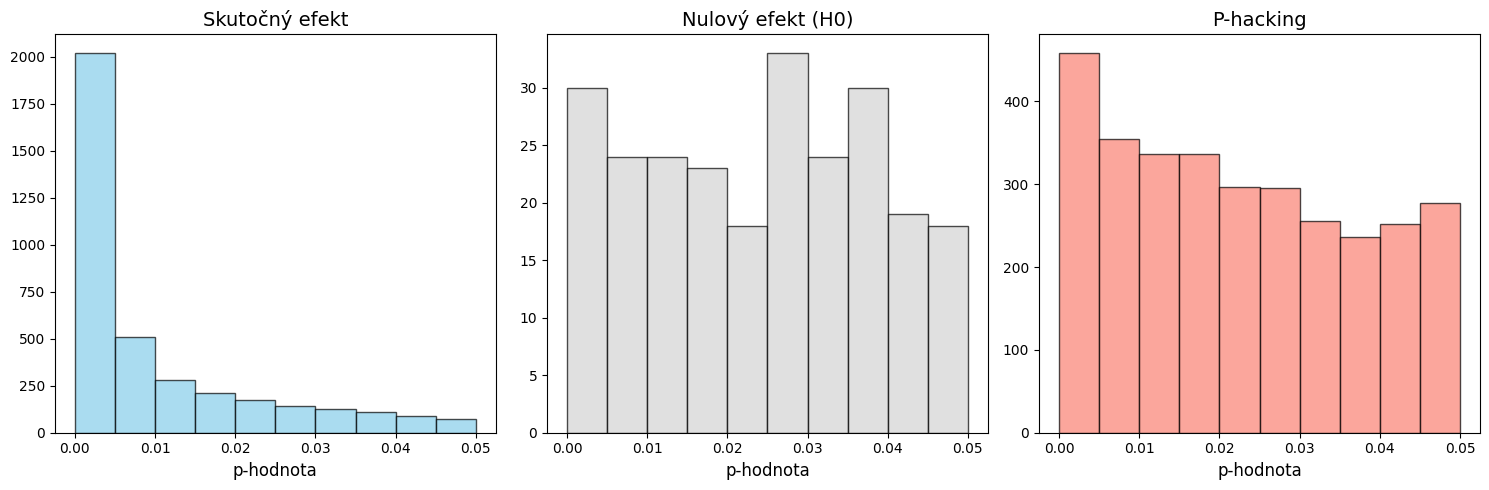

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def simulate_p_curves(n_studies=5000, sample_size=30):
    
    np.random.seed(42)
    
    p_real_effect = []
    p_null_effect = []
    p_hacked = []

    for _ in range(n_studies):
        # skutocny efekt
        data_real = np.random.normal(loc=0.5, scale=1.0, size=sample_size)
        _, p = stats.ttest_1samp(data_real, 0)
        if p < 0.05: p_real_effect.append(p)

        # nulovy efekt - rovnomerne rozlozene p-hodnoty
        data_null = np.random.normal(loc=0.0, scale=1.0, size=sample_size)
        _, p = stats.ttest_1samp(data_null, 0)
        if p < 0.05: p_null_effect.append(p)

        # p-hacking
        hacked_p = 1.0
        for extra_n in range(10, 50, 5): # Postupne pridávanie dát
            data_hacked = np.random.normal(loc=0.1, scale=1.0, size=sample_size + extra_n)
            _, p = stats.ttest_1samp(data_hacked, 0)
            # zastavenie zberu po ziskani signifikantneho vysledku
            if p < 0.05:
                hacked_p = p
                break
        if hacked_p < 0.05: p_hacked.append(hacked_p)

    # Vykreslenie
    plt.figure(figsize=(15, 5))
    bins = np.linspace(0, 0.05, 11)

    # Graf skutocneho efektu
    plt.subplot(1, 3, 1)
    plt.hist(p_real_effect, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title('Skutočný efekt',fontsize=14)
    plt.xlabel('p-hodnota',fontsize=12)

    # Graf nuloveho efektu
    plt.subplot(1, 3, 2)
    plt.hist(p_null_effect, bins=bins, color='lightgrey', edgecolor='black', alpha=0.7)
    plt.title('Nulový efekt (H0)',fontsize=14)
    plt.xlabel('p-hodnota',fontsize=12)

    # Graf p-hackingu
    plt.subplot(1, 3, 3)
    plt.hist(p_hacked, bins=bins, color='salmon', edgecolor='black', alpha=0.7)
    plt.title('P-hacking',fontsize=14)
    plt.xlabel('p-hodnota',fontsize=12)

    plt.tight_layout()
    plt.savefig("pcurveanalyzaGrafy",dpi=300)
    plt.show()

simulate_p_curves()